In [1]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import sys
import seaborn as sns
#sys.path.insert(0, '/Users/eduardomorenoortiz/Desktop/ITAM/nanook/nlp_nanook/src') # Local
sys.path.insert(0, r'C:\Users\eduardo.moreno\OneDrive - NEORIS\Desktop\courses\nlp\nlp_nanook\src') # Windows
from utils.utils import formato_abreviado, generate_N_grams, clean_text, get_corpus_N_gram
from matplotlib.ticker import FuncFormatter
from collections import Counter

# Exploratory Data Analysis (EDA)

## Read and preprocess data

In [2]:
data = pd.read_pickle(r'..\..\..\data\preprocessed\data_fb_pages.pkl')

In [3]:
data.columns

Index(['Entity Name', 'Facebook Id', 'Likes at Posting', 'Post Created',
       'Type', 'Total Interactions', 'Likes', 'Comments', 'Shares', 'Love',
       'Wow', 'Haha', 'Sad', 'Angry', 'Care', 'Message', 'Image Text',
       'Link Text', 'Description', 'score', 'source'],
      dtype='object')

In [4]:
df_selected = data[['Facebook Id', 'Likes at Posting', 'Post Created', 'Type', 
                    'Total Interactions', 'Likes', 'Comments', 'Shares', 'Love', 'Wow', 'Haha', 'Sad', 'Angry', 'Care', 'Message', 'Image Text', 'Link Text', 'Description', 
                    'score']]

In [5]:
df_selected.head()

,Facebook Id,Likes at Posting,Post Created,Type,Total Interactions,Likes,Comments,Shares,Love,Wow,Haha,Sad,Angry,Care,Message,Image Text,Link Text,Description,score
0,97984508920,NaN,2014-12-31 23:29:00 CST,Link,13,9,2,2,0,0,0,0,0,0,Energía #nuclear es buena y clave para la solu...,NaN,Energía nuclear es buena y clave para la soluc...,"Al no quemar combustibles fósiles, no generan ...",-50.92
1,100050454251406,NaN,2014-12-31 22:09:49 CST,Status,44,38,0,6,0,0,0,0,0,0,El cambio climático debería generar la misma a...,NaN,NaN,NaN,1.63
2,100064702265343,NaN,2014-12-31 18:56:14 CST,Link,7,3,1,3,0,0,0,0,0,0,SIN NOSOTRAS NO HAY REVOLUCIÓN,NaN,¿Por qué la resistencia de las mujeres frente ...,Es obvio que el capitalismo se nutre y sostien...,-0.5
3,135613897055,NaN,2014-12-31 18:00:17 CST,Link,43,37,0,6,0,0,0,0,0,0,"Percy Grandez, especialista en Derecho Ambient...",NaN,Sector Ambiente: Algunos sucesos que marcaron ...,"Temas de actualidad jurídica, social y económi...",-1.65
4,260339100808879,NaN,2014-12-31 17:33:59 CST,Link,0,0,0,0,0,0,0,0,0,0,Sólo una sexta parte de la cobertura original ...,NaN,Climate Change Isn’t Main Culprit in Decline o...,"And if things stay the way they are, most Cari...",-34


In [6]:
df_selected.shape

(1106405, 19)

Drop *nan* inside `Message` column

In [7]:
print(f"Cantidad de NAN: {sum([1 if pd.isna(x) else 0 for x in df_selected['Message']])}")
print(f"Cantidad de NAN (%): {round(sum([1 if pd.isna(x) else 0 for x in df_selected['Message']])/df_selected.shape[0]*100, 5)}%")
df_clean = df_selected.dropna(subset=['Message'])

Cantidad de NAN: 793
Cantidad de NAN (%): 0.07167%


In [8]:
df_clean = df_clean.reset_index()

Show some messages

In [9]:
random.seed(14112023)
for i in random.sample(range(0, df_clean.shape[0]), 10):
    print(df_clean['Message'][i])
    print('\n')

[Publicación] El IDEHPUCP publicó el libro Cambio Climático y derechos humanos (2020). El volumen, coordinado por Elizabeth Salmón, reúne trabajos de autores y autoras de amplia trayectoria. 👉 Disponible en el Fondo Editorial PUCP y la plataforma Bookwire. 🔴 Accede a la reseña del libro aquí: https://bit.ly/3kzuM1h:=:https://idehpucp.pucp.edu.pe/notas-informativas/resena-cambio-climatico-y-derechos-humanos/


#AlMomento #Chalchicomula #Incendio Nos llega una denuncia ciudadana sobre un incendio a fueras de la comunidad de Santa Ines, la cual pertenece al municipio de Chalchicomula de Sesma. Usted juzgue, despues de la contingencia que vivimos, el calentamiento global, y la falta de agua en el municipio, simplemente se les ocurre prender fuego a pasto seco.


Esto puede ocurrir en 130 año...


Greta Thunberg rechaza ecocidio en las costas venezolanas por derrame de crudo en Sucre #16Ago - La joven activista sueca icono mundial en la lucha contra el cambio climático, Greta Thunberg, reac

### Length of Messages

In [10]:
df_clean['messageChar_length'] = [x if pd.isna(x) else len(x) for x in df_clean['Message']]
df_clean['messageWords_length'] = [x if pd.isna(x) else len(x.split(' ')) for x in df_clean['Message']]

<Axes: ylabel='Frequency'>

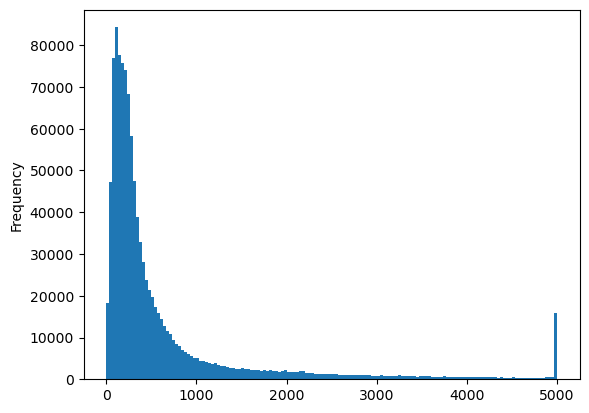

In [11]:
df_clean['messageChar_length'].plot(bins=150, kind='hist')

It is curious that there are "a lot" of messages with length aproximatly to $5,000$

In [12]:
df_clean['messageChar_length'].describe()

count    1.105612e+06
mean     6.359114e+02
std      9.490124e+02
min      1.000000e+00
25%      1.560000e+02
50%      2.830000e+02
75%      6.070000e+02
max      5.000000e+03
Name: messageChar_length, dtype: float64

In [ ]:
for x in df_clean[df_clean['messageChar_length'] == 4999]['Message']:
    print(x[-20:])

 pobreza (truncated)
 ley del (truncated)
ecesario (truncated)
, y unos (truncated)
e estima (truncated)
llevaron (truncated)
otoBlog, (truncated)
ones del (truncated)
peratura (truncated)
ideraban (truncated)
fundas y (truncated)
Torrico. (truncated)
onsables (truncated)
a calle, (truncated)
cimiento (truncated)
bilidad. (truncated)
 en 2017 (truncated)
cimiento (truncated)
 países? (truncated)
océanos, (truncated)
torio de (truncated)
ntrol de (truncated)
ero sólo (truncated)
LA ÉPOCA (truncated)
 vida en (truncated)
urístico (truncated)
ero sólo (truncated)
 a la 5ª (truncated)
ienen al (truncated)
e, donde (truncated)
brientos (truncated)
stado de (truncated)
os donde (truncated)
ero sólo (truncated)
hasta tu (truncated)
opuestas (truncated)
minacion (truncated)
hat ¡POR (truncated)
 espacio (truncated)
zados el (truncated)
existía, (truncated)
 la isla (truncated)
na marcó (truncated)
 interés (truncated)
cidad de (truncated)
 NUESTRA (truncated)
entes se (truncated)
ectaría, (tru

Seems that facebook messages/publications are truncated to $4,999$ characters!

<Axes: ylabel='Frequency'>

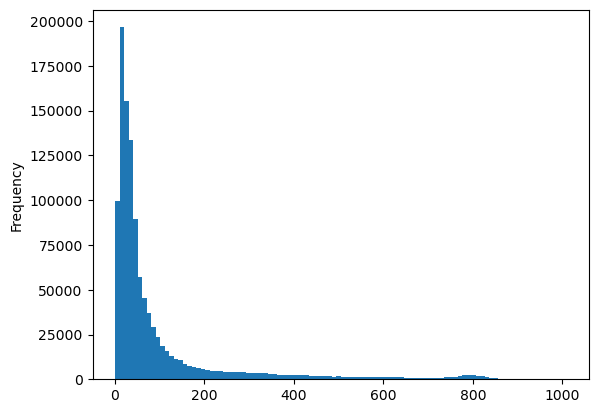

In [ ]:
df_clean['messageWords_length'].plot(bins=100, kind='hist')

## N-grams

### Uni-gram

#### Raw

First, let's analyze text from **raw** (without any changes)

Length of corpus: 105718392


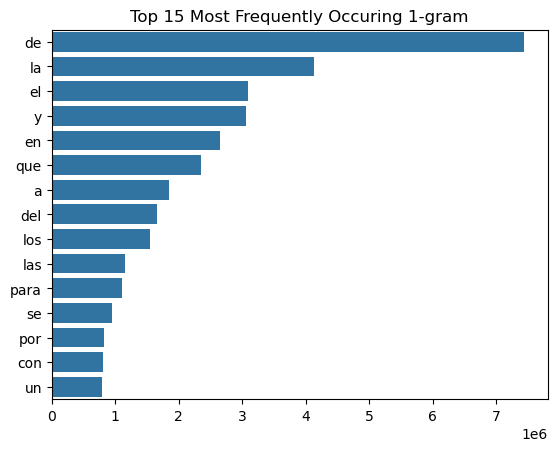

In [ ]:
corpus = get_corpus_N_gram(list_text=df_clean['Message'], stop_words=None, ngram=1, show_plot=True)

Those are meaningless words, all of them (and similar) will be added to **stopwords**, so they won't be use for future analysis. 

#### With stop-words

In [ ]:
with open(r'..\..\utils\spanish_stopwords.txt', 'r') as archivo:
    stop_words = [linea.strip() for linea in archivo]
len(stop_words)

608

In [ ]:
stop_words[:10]

['a',
 'actualmente',
 'adelante',
 'además',
 'afirmó',
 'agregó',
 'ahora',
 'ahí',
 'al',
 'algo']

Length of corpus: 58301786


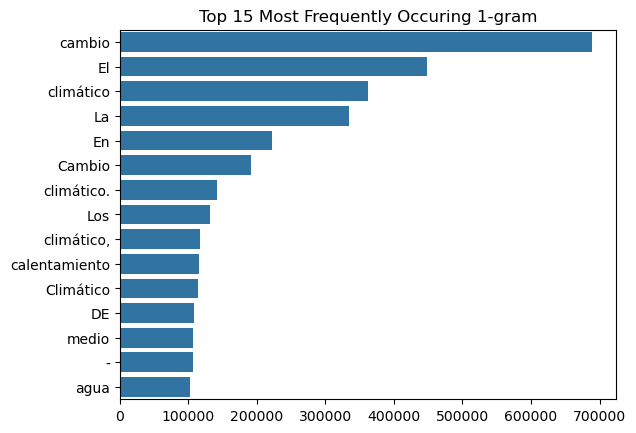

In [ ]:
corpus = get_corpus_N_gram(list_text=df_clean['Message'], stop_words=stop_words, ngram=1, show_plot=True)

- Upper/Lower-case must be removed, so that "*Cambio*" and "*cambio*" are counted in the same word.
- It is suggested by the autor to remove accents
- No include punctiations signs: **, ; . : '**
- No include URLs inside text

#### Stop-words, text to lowercase, no URLs: clean text

In [ ]:
df_clean['Message_clean'] = df_clean['Message'].apply(lambda x: clean_text(x))

Length of corpus: 54901123


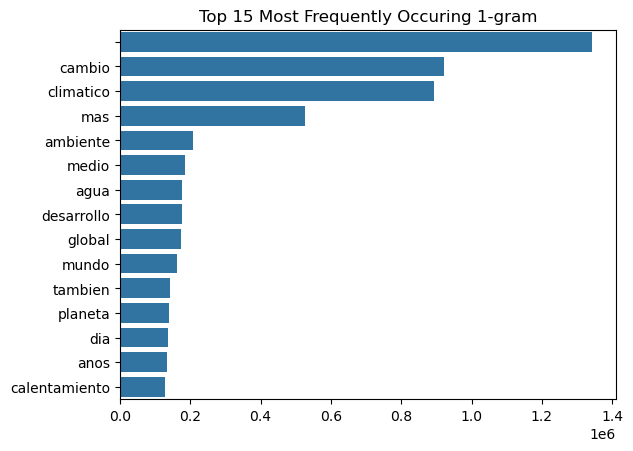

In [ ]:
corpus = get_corpus_N_gram(list_text=df_clean['Message_clean'], stop_words=stop_words, ngram=1, show_plot=True)

### Bi-gram

Length of corpus: 53795921


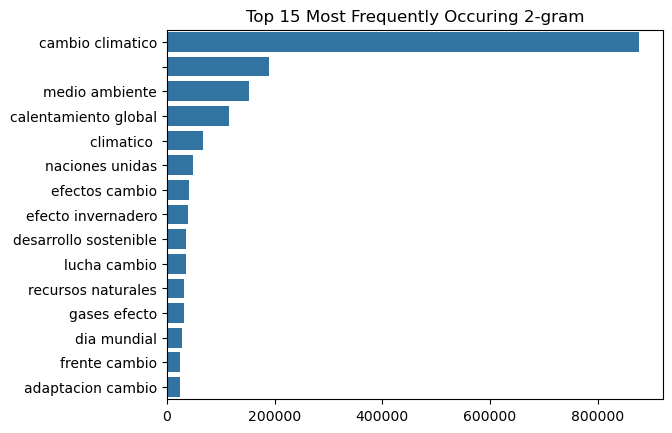

In [ ]:
corpus = get_corpus_N_gram(list_text=df_clean['Message_clean'], stop_words=stop_words, ngram=2, show_plot=True)

### Tri-gram

Length of corpus: 52694843


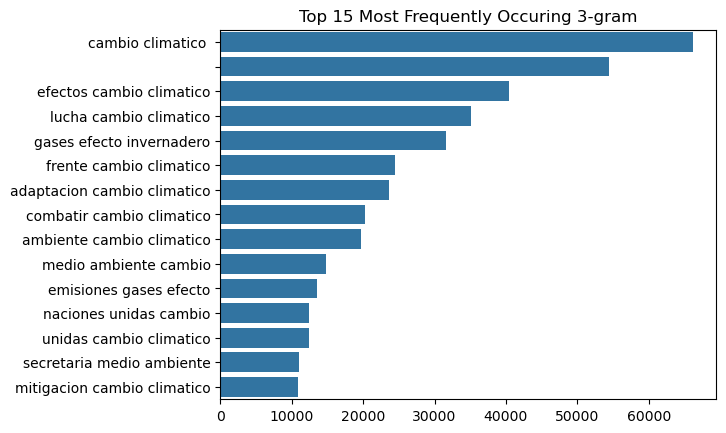

In [ ]:
corpus = get_corpus_N_gram(df_clean['Message_clean'], stop_words=stop_words, ngram=3, show_plot=True)

In [ ]:
df_clean.to_pickle(r'..\..\..\data\preprocessed\clean_text_fb_pages_nanook.pkl')